In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('airtel Customer.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 churn column has records of customers who have switched to other company

*# tenure column has records of customers length of time they have been using services

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Checking for duplicate values in customerID

df['customerID'].duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

Converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [ ]:
df['SeniorCitizen']

,SeniorCitizen
0,no
1,no
2,no
3,no
4,no
...,...
7038,no
7039,no
7040,no
7041,yes


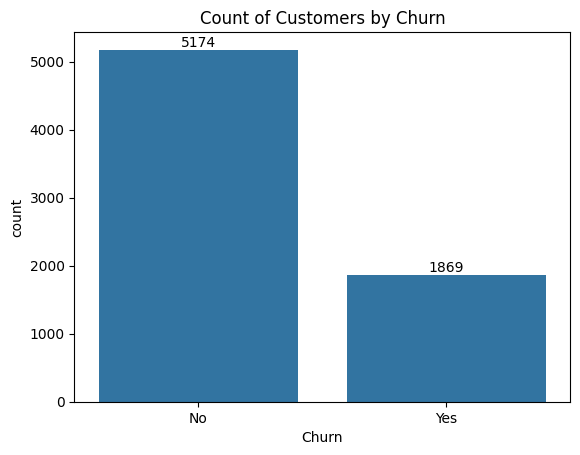

In [ ]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

## Conclusion : 1869 customers have churned out.

In [ ]:
df['Churn']


,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


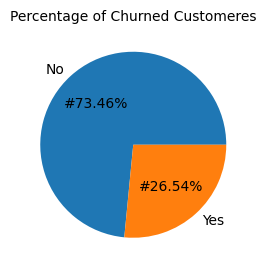

In [ ]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "#%1.2f%%")           #%1.2f%%
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

# autopct is to display the percent value.

# Conclusion : From the given pie chart we can conclude that 26.54% of our customers have churned out.

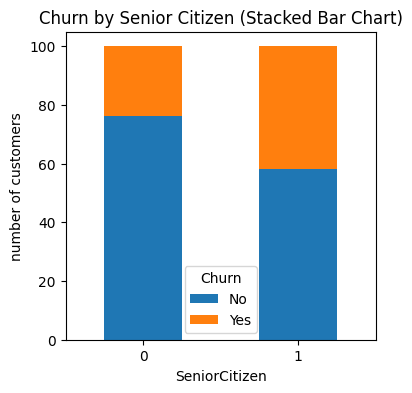

In [ ]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() *100


# Plot
fig, ax = plt.subplots(figsize=(4, 4))

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax)

# STACK means displacement of overlapping bars.


plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('number of customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

# Conclusion : Comparative a significant number of people in senior citizen category have churned out.

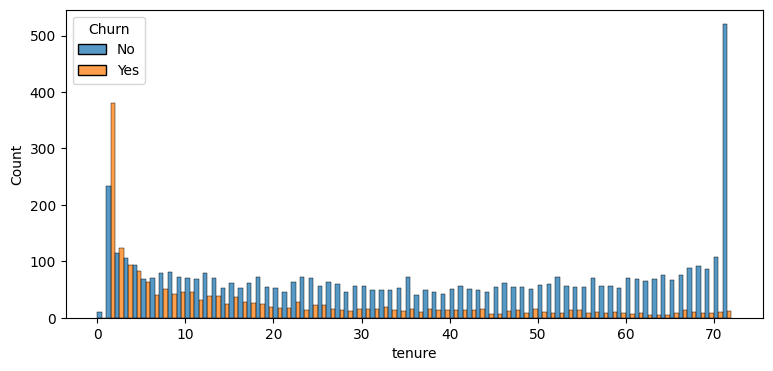

In [ ]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn", multiple='dodge')
plt.show()

# Conclusion : People who have used our services for a long time have stayed and people who have used our sevices few months have churned


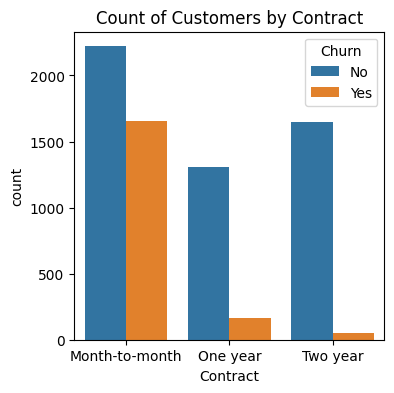

In [ ]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")

plt.title("Count of Customers by Contract")
plt.show()

# Conclusion : People who have month to month contract are likely to churn then from those who have 1 or 2 years or contract.

# Task 4: Show number of customers who have churned out according to our services.

In [ ]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

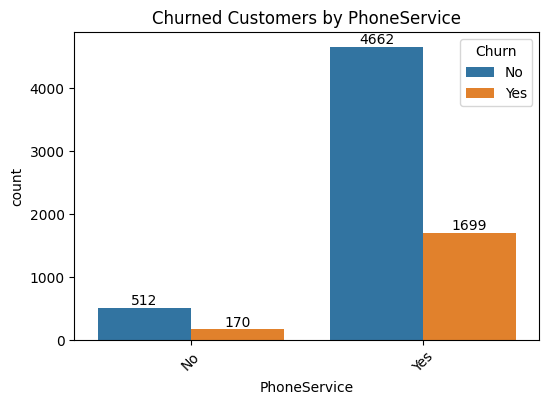

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PhoneService", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by PhoneService")
plt.xticks(rotation = 45)
plt.show()

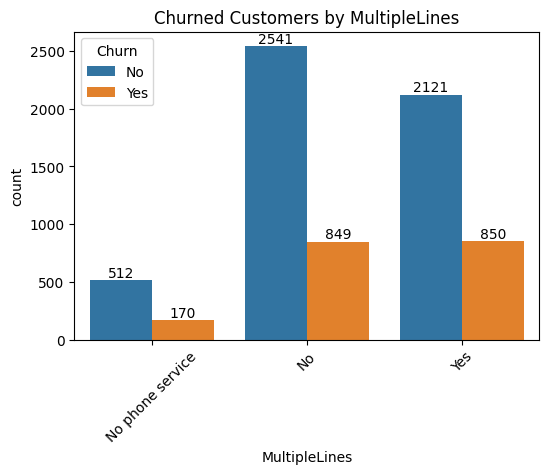

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "MultipleLines", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by MultipleLines")
plt.xticks(rotation = 45)
plt.show()

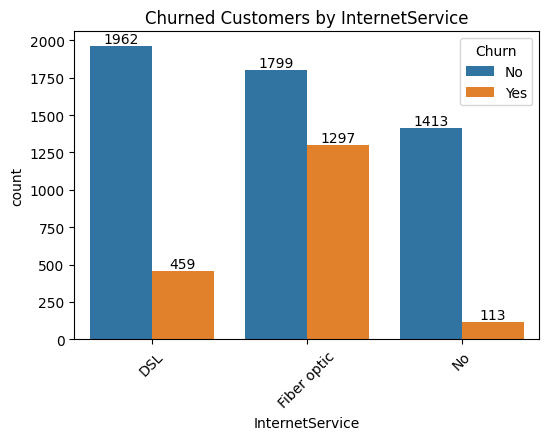

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "InternetService", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by InternetService")
plt.xticks(rotation = 45)
plt.show()

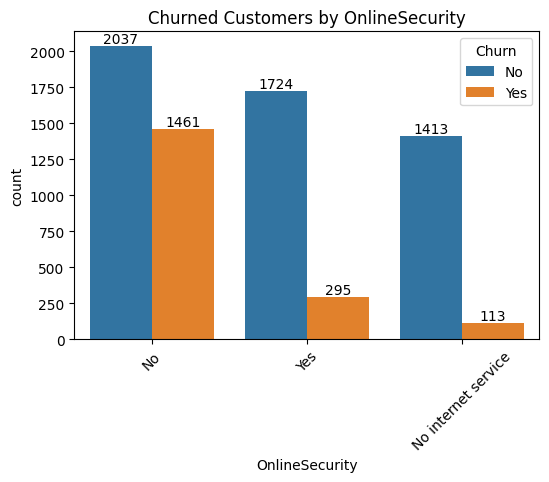

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "OnlineSecurity", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by OnlineSecurity")
plt.xticks(rotation = 45)
plt.show()

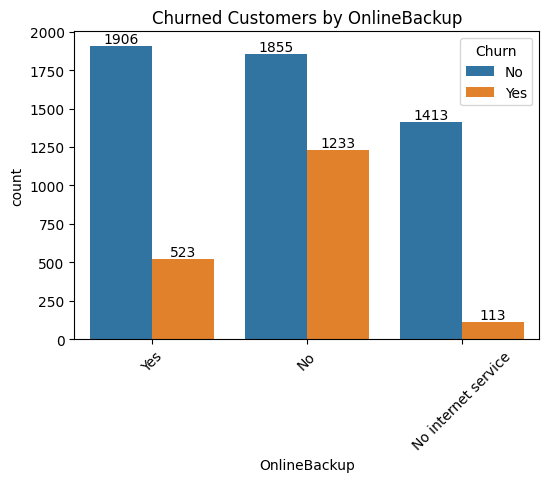

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "OnlineBackup", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by OnlineBackup")
plt.xticks(rotation = 45)
plt.show()

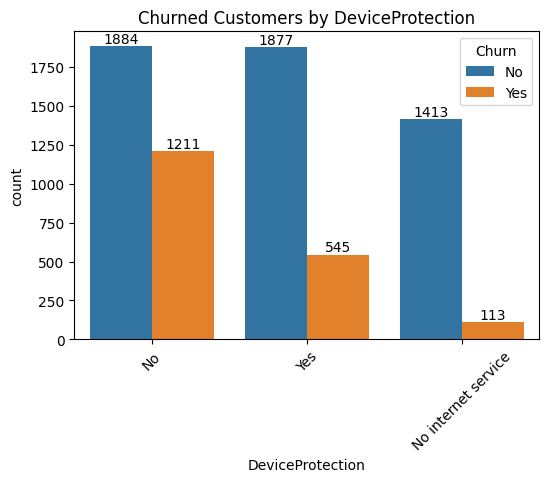

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "DeviceProtection", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by DeviceProtection")
plt.xticks(rotation = 45)
plt.show()

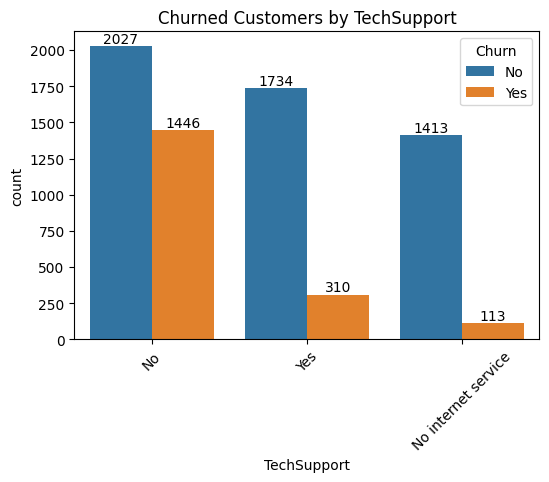

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "TechSupport", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by TechSupport")
plt.xticks(rotation = 45)
plt.show()

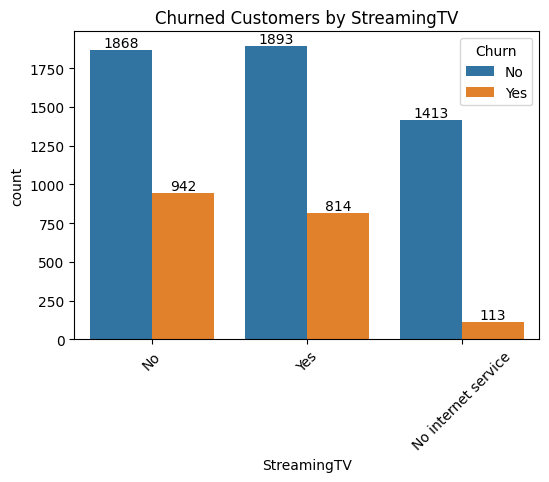

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "StreamingTV", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by StreamingTV")
plt.xticks(rotation = 45)
plt.show()

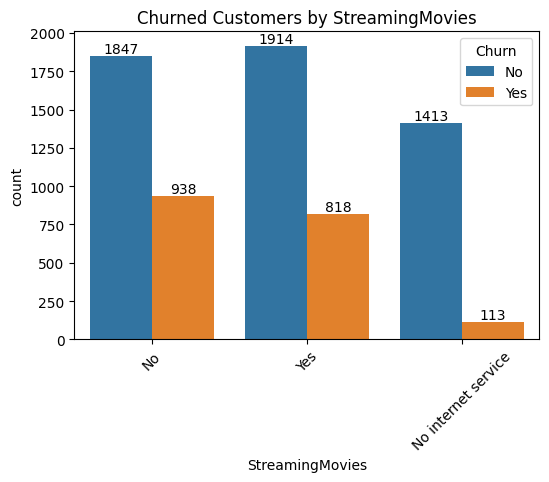

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "StreamingMovies", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by StreamingMovies")
plt.xticks(rotation = 45)
plt.show()

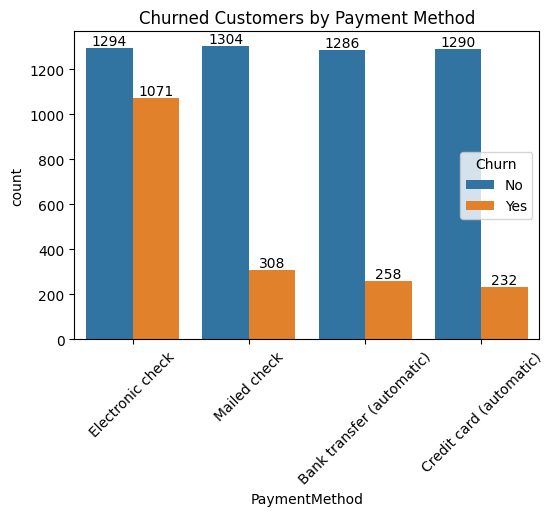

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

# We  will  inspect    churnig    of     each  service

In [ ]:
dict1={'PhoneService' : 1699, 'MultipleLines' : 849, 'InternetServices' : 1297,
       'OnlineSecurity' : 1461, 'OnlineBackup' : 1233, 'DeviceProtection' : 1211,
       'TechSupport' : 1446, 'StreamingTV' : 942, 'StreamingMovies' : 938,
       'PaymentMethod' : 1071}

In [ ]:
dict1

{'PhoneService': 1699,
 'MultipleLines': 849,
 'InternetServices': 1297,
 'OnlineSecurity': 1461,
 'OnlineBackup': 1233,
 'DeviceProtection': 1211,
 'TechSupport': 1446,
 'StreamingTV': 942,
 'StreamingMovies': 938,
 'PaymentMethod': 1071}

# Conclusion : Maximum Churning is in PhoneService i.e 1699